# Preprocessing and merging trip data with maintenance records

In [23]:
import pandas as pd
from pathlib import Path
import os
import numpy as np
from geopy.distance import geodesic
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from lifelines import WeibullFitter
import math
import numpy as np
import pandas as pd
import folium
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import datetime
from pathlib import Path
import os
import pandas as pd
from tabulate import tabulate


# Load cleaned data

In [24]:
# =========================================================
# CLEAN DATA LOADER (Trip + Damage + Maintenance ONLY)
# =========================================================

import os
from pathlib import Path
import pandas as pd
from tabulate import tabulate


def load_clean_data(base_folder="US_data"):
    """
    Loads:
        - trip_data_clean.csv
        - processed maintenance CSV files (damage + maintenance only)
    Excludes repair files.
    """

    notebook_dir = Path(os.getcwd())

    trip_clean_path = notebook_dir / "trip_data" / "processed" / "trip_data_clean.csv"
    maintenance_dir = notebook_dir / "maintenance_data" / "processed"

    # -------------------------
    # Load Trip Data
    # -------------------------
    trip_data_clean = (
        pd.read_csv(trip_clean_path, parse_dates=["position_at"])
        if trip_clean_path.exists()
        else pd.DataFrame()
    )

    # -------------------------
    # Load Maintenance Data
    # -------------------------
    maint_store = {"damage": [], "maintenance": []}
    maintenance_files = sorted(maintenance_dir.glob("*.csv"))

    for file in maintenance_files:
        fname = file.name.lower()

        # Skip repair files completely
        if "repair" in fname:
            continue

        df = pd.read_csv(file)

        category = "damage" if "damage" in fname else "maintenance"
        maint_store[category].append(df)

    damage_data = (
        pd.concat(maint_store["damage"], ignore_index=True)
        if maint_store["damage"] else pd.DataFrame()
    )

    maintenance_data = (
        pd.concat(maint_store["maintenance"], ignore_index=True)
        if maint_store["maintenance"] else pd.DataFrame()
    )

    # -------------------------
    # Summary
    # -------------------------
    summary = [
        ["Trip rows", f"{len(trip_data_clean):,}"],
        ["Trip columns", trip_data_clean.shape[1]],
        ["Maintenance files found", len(maintenance_files)],
        ["Damage logs", f"{len(damage_data):,}"],
        ["Maintenance logs", f"{len(maintenance_data):,}"],
    ]

    print("\n" + "="*50)
    print("CLEAN DATA LOAD SUMMARY")
    print("="*50)
    print(tabulate(summary, headers=["Metric", "Value"], tablefmt="github"))
    print("="*50)

    return trip_data_clean, damage_data, maintenance_data

In [25]:
trip_data, damage_data, maintenance_data = load_clean_data()


CLEAN DATA LOAD SUMMARY
| Metric                  | Value     |
|-------------------------|-----------|
| Trip rows               | 7,635,727 |
| Trip columns            | 23        |
| Maintenance files found | 2         |
| Damage logs             | 7,673     |
| Maintenance logs        | 38,684    |


# Feature engineering for weibull distribution

## Aggregate distace per trip

In [26]:
# ---------------------------------------------------------------
# Aggregate strictly by trip_id
# ---------------------------------------------------------------
usage_ref = (
    trip_data.groupby(['vehicle_id', 'trip_id', 'trip_ended_at'])
    .agg({
        'dist_km': 'sum',                          # Sum all pings in this trip
        'trip_start_dock_group_title': 'first',     # Get the start station name
        'trip_end_dock_group_title': 'first'        # Get the end station name
    })
    .reset_index()
    .rename(columns={'dist_km': 'trip_km'})
)

# Convert to datetime
#usage_ref['trip_ended_at'] = pd.to_datetime(usage_ref['trip_ended_at'])

# ---------------------------------------------------------------
# Calculate the Odometer 
# ---------------------------------------------------------------
usage_ref = usage_ref.sort_values(['vehicle_id', 'trip_ended_at'])
usage_ref['odometer_km'] = usage_ref.groupby('vehicle_id')['trip_km'].cumsum()

## Cumulative trip calculation

In [27]:
# ---------------------------------------------------------------
# Calculate Cumulative Trips (For cycle-based fatigue analysis)
# ---------------------------------------------------------------
# Since each row in usage_ref represents one distinct trip and is already 
# sorted chronologically, we just count the rows per vehicle.
usage_ref['cumulative_trips'] = usage_ref.groupby('vehicle_id').cumcount() + 1

# Optional: You can also calculate the lifetime average trip density right here
# (Total trips / Total km). We add a small number (e.g., 0.001) to avoid division by zero.
usage_ref['lifetime_trips_per_km'] = usage_ref['cumulative_trips'] / (usage_ref['odometer_km'] + 0.001)

print("Usage reference updated with cumulative trips and trip density.")
display(usage_ref[['vehicle_id', 'trip_ended_at', 'trip_km', 'odometer_km', 'cumulative_trips']].head())

Usage reference updated with cumulative trips and trip density.


,vehicle_id,trip_ended_at,trip_km,odometer_km,cumulative_trips
0,18,2023-04-16 14:37:24.745,1.725272,1.725272,1
1,18,2023-04-16 15:18:47.296,0.860731,2.586003,2
2,18,2023-04-18 10:53:45.852,1.436417,4.022420,3
3,18,2023-04-18 12:58:14.804,1.713684,5.736104,4
4,18,2023-04-19 11:08:06.844,2.284369,8.020473,5


### Sanity check on odometer for vehicle_id = 3960

In [28]:
'''from tabulate import tabulate

v_id = 3960
v_usage = usage_ref[usage_ref['vehicle_id'] == v_id].copy()

# Formatting for the table
v_usage['Time'] = v_usage['trip_ended_at'].dt.strftime('%H:%M:%S')
v_usage['Start Stat'] = v_usage['trip_start_dock_group_title'].fillna("-").str[:15]
v_usage['End Stat'] = v_usage['trip_end_dock_group_title'].fillna("-").str[:15]

# Selection - we dropped 'Prev End' because it was causing the row splitting
display_cols = ['Time', 'trip_id', 'Start Stat', 'End Stat', 'trip_km', 'odometer_km']
headers = ['Time', 'Trip ID', 'Start Stat', 'End Stat', 'Trip KM', 'Odometer KM']

print(f"\n=== CLEANED ODOMETER AUDIT: VEHICLE {v_id} ===")
print(tabulate(
    v_usage[display_cols], 
    headers=headers, 
    tablefmt="psql", 
    showindex=False,
    floatfmt=".2f"
))'''

'from tabulate import tabulate\n\nv_id = 3960\nv_usage = usage_ref[usage_ref[\'vehicle_id\'] == v_id].copy()\n\n# Formatting for the table\nv_usage[\'Time\'] = v_usage[\'trip_ended_at\'].dt.strftime(\'%H:%M:%S\')\nv_usage[\'Start Stat\'] = v_usage[\'trip_start_dock_group_title\'].fillna("-").str[:15]\nv_usage[\'End Stat\'] = v_usage[\'trip_end_dock_group_title\'].fillna("-").str[:15]\n\n# Selection - we dropped \'Prev End\' because it was causing the row splitting\ndisplay_cols = [\'Time\', \'trip_id\', \'Start Stat\', \'End Stat\', \'trip_km\', \'odometer_km\']\nheaders = [\'Time\', \'Trip ID\', \'Start Stat\', \'End Stat\', \'Trip KM\', \'Odometer KM\']\n\nprint(f"\n=== CLEANED ODOMETER AUDIT: VEHICLE {v_id} ===")\nprint(tabulate(\n    v_usage[display_cols], \n    headers=headers, \n    tablefmt="psql", \n    showindex=False,\n    floatfmt=".2f"\n))'

## Merging Damage Reports with Odometer State

In [29]:
# ---------------------------------------------------------------
# Prepare for merge_asof by sorting columns
# ---------------------------------------------------------------
usage_ref['trip_ended_at'] = pd.to_datetime(usage_ref['trip_ended_at'])
usage_ref = usage_ref.sort_values('trip_ended_at').reset_index(drop=True)

damage_data['created_at'] = pd.to_datetime(damage_data['created_at'])
damage_data = damage_data.sort_values('created_at').reset_index(drop=True)

In [30]:
# 3. Perform the merge
damage_with_usage = pd.merge_asof(
    damage_data,
    usage_ref,
    left_on='created_at',
    right_on='trip_ended_at',
    by='vehicle_id',
    direction='backward'
)

# 4. Fill odometer
damage_with_usage['odometer_km'] = damage_with_usage['odometer_km'].fillna(0)

print("\n" + "="*60)
print("MERGE COMPLETE")
print("="*60)
print(f"Damage events with odometer data: {len(damage_with_usage):,}")
print(f"Events at 0km (pre-first-trip):   {(damage_with_usage['odometer_km'] == 0).sum():,}")


MERGE COMPLETE
Damage events with odometer data: 7,673
Events at 0km (pre-first-trip):   716


In [31]:
"""damage_with_usage = damage_with_usage.sort_values(['vehicle_id', 'damage_category', 'odometer_km'])

# Calculate km since last failure of SAME category
damage_with_usage['km_since_last_failure'] = damage_with_usage.groupby(
    ['vehicle_id', 'damage_category']
)['odometer_km'].diff()


# Identify the first failure in 2024 for each bike/category (where diff is NaN)
is_first_failure = damage_with_usage['km_since_last_failure'].isna()

# For the first failure, the known distance is the odometer reading since the start of 2024
damage_with_usage.loc[is_first_failure, 'km_since_last_failure'] = damage_with_usage.loc[is_first_failure, 'odometer_km']

# Create the event observation flag dynamically!
# 1 = We know the exact lifespan (these are the subsequent failures in 2024)
# 0 = Right-censored (this is the first failure; we know it survived AT LEAST this long)
damage_with_usage['event_observed'] = np.where(is_first_failure, 0, 1)"""
#############
# --- 1. PREPARE USAGE_REF WITH TRIP COUNTS (FULL HISTORY) ---
usage_ref = usage_ref.sort_values(['vehicle_id', 'trip_ended_at'])
# Calculate lifetime trip count across 2023 and 2024
usage_ref['lifetime_trip_count'] = usage_ref.groupby('vehicle_id').cumcount() + 1

# --- 2. MERGE ODOMETER AND TRIP COUNTS ---
damage_data = damage_data.sort_values('created_at').reset_index(drop=True)
usage_ref = usage_ref.sort_values('trip_ended_at').reset_index(drop=True)

damage_data = pd.merge_asof(
    damage_data,
    usage_ref[['vehicle_id', 'trip_ended_at', 'odometer_km', 'lifetime_trip_count']],
    left_on='created_at',
    right_on='trip_ended_at',
    by='vehicle_id',
    direction='backward'
)
damage_data['odometer_km'] = damage_data['odometer_km'].fillna(0)
damage_data['lifetime_trip_count'] = damage_data['lifetime_trip_count'].fillna(0)

# --- 3. CALCULATE INTERVALS (FULL HISTORY) ---
damage_data = damage_data.sort_values(['vehicle_id', 'damage_category', 'created_at'])

# Calculate KM and Trips since last failure
damage_data['km_since_last_failure'] = damage_data.groupby(['vehicle_id', 'damage_category'])['odometer_km'].diff()
damage_data['trips_since_last_failure'] = damage_data.groupby(['vehicle_id', 'damage_category'])['lifetime_trip_count'].diff()

# --- 4. CREATE 2024 ANALYTICS SUBSET ---
damage_with_usage = damage_data[damage_data['created_at'].dt.year == 2024].copy()

# Handle the first failures of the year
is_first_failure = damage_with_usage['km_since_last_failure'].isna()

# Fallback to odometer/lifetime count if no 2023 history exists
damage_with_usage.loc[is_first_failure, 'km_since_last_failure'] = damage_with_usage.loc[is_first_failure, 'odometer_km']
damage_with_usage.loc[is_first_failure, 'trips_since_last_failure'] = damage_with_usage.loc[is_first_failure, 'lifetime_trip_count']

# Set the observation flag
damage_with_usage['event_observed'] = np.where(is_first_failure, 0, 1)

#################


# Filter noise (failures too close together - likely data artifacts)
#MIN_DISTANCE_KM = 10.0
before_filter = len(damage_with_usage)
#damage_with_usage = damage_with_usage[damage_with_usage['km_since_last_failure'] > MIN_DISTANCE_KM]
damage_with_usage = damage_with_usage[damage_with_usage['km_since_last_failure'] > 0].copy() # We keep all events that are more than 0km apart, which means we only remove duplicates at the same odometer reading (potential data errors)
after_filter = len(damage_with_usage)

print(f"\nNoise Filtering:")
#print(f"  Events <{MIN_DISTANCE_KM}km apart: {before_filter - after_filter:,}")
print(f"  Final events for Weibull:  {after_filter:,}")

print("\n" + "="*60)
print("INTER-ARRIVAL DISTANCE STATISTICS (km)")
print("="*60)
print(damage_with_usage.groupby('damage_category')['km_since_last_failure'].describe())


Noise Filtering:
  Final events for Weibull:  3,847

INTER-ARRIVAL DISTANCE STATISTICS (km)
                    count        mean         std       min         25%  \
damage_category                                                           
Body & Accessories  672.0  242.035606  246.720063  0.033358   67.651351   
Braking System      849.0  152.254858  211.170156  0.004974   15.327338   
Drivetrain          869.0  157.531233  197.001223  0.004973   21.442831   
Electronics         274.0  381.082644  350.765830  1.135657  177.462537   
Steering & Chassis  605.0  226.237229  237.457192  0.004974   42.856093   
Wheels & Tires      578.0  238.206969  264.191210  0.004972   40.908412   

                           50%         75%          max  
damage_category                                          
Body & Accessories  173.270907  338.546607  2704.051448  
Braking System       59.594715  227.329433  1999.406386  
Drivetrain           78.591710  228.508792  1636.082807  
Electronics     

# Plotting histograms

## Trying to add number of trips

In [32]:
import pandas as pd
import numpy as np

"""# 1. Calculate the 'Lifetime Trip Count' for every trip in your main usage reference
usage_ref = usage_ref.sort_values(['vehicle_id', 'trip_ended_at'])
usage_ref['lifetime_trip_count'] = usage_ref.groupby('vehicle_id').cumcount() + 1

# 2. Merge this new count directly into your damage dataset
# We use a left merge on the exact vehicle and trip end time to snap the count into place
damage_with_usage = pd.merge(
    damage_with_usage,
    usage_ref[['vehicle_id', 'trip_ended_at', 'lifetime_trip_count']],
    on=['vehicle_id', 'trip_ended_at'],
    how='left'
)

# 3. Calculate "Trips Since Last Failure" (using the exact same logic we used for kilometers)
damage_with_usage = damage_with_usage.sort_values(['vehicle_id', 'damage_category', 'created_at'])
damage_with_usage['trips_since_last_failure'] = damage_with_usage.groupby(
    ['vehicle_id', 'damage_category']
)['lifetime_trip_count'].diff()"""

###########
# --- 1. PREPARE CONTINUOUS USAGE REFERENCE ---
# Sort by bike and time across the ENTIRE dataset (2023 + 2024)
usage_ref = usage_ref.sort_values(['vehicle_id', 'trip_ended_at'])

# Calculate Continuous Odometer
usage_ref['odometer_km'] = usage_ref.groupby('vehicle_id')['trip_km'].cumsum()

# Calculate Continuous Lifetime Trip Count
usage_ref['lifetime_trip_count'] = usage_ref.groupby('vehicle_id').cumcount() + 1

# --- 2. SYNC DAMAGE WITH USAGE ---
# Ensure damage_with_usage has the latest usage metrics merged in
# (Assuming damage_with_usage was already filtered to your study period)
damage_with_usage = pd.merge(
    damage_with_usage.drop(columns=['odometer_km', 'lifetime_trip_count'], errors='ignore'),
    usage_ref[['vehicle_id', 'trip_ended_at', 'odometer_km', 'lifetime_trip_count']],
    on=['vehicle_id', 'trip_ended_at'],
    how='left'
)

# --- 3. CALCULATE INTERVALS (KM & TRIPS) ---
# Sort to ensure intervals are calculated in chronological order
damage_with_usage = damage_with_usage.sort_values(['vehicle_id', 'damage_category', 'created_at'])

# Calculate differences between current and previous failure for that bike/category
damage_with_usage['km_since_last_failure'] = damage_with_usage.groupby(['vehicle_id', 'damage_category'])['odometer_km'].diff()
damage_with_usage['trips_since_last_failure'] = damage_with_usage.groupby(['vehicle_id', 'damage_category'])['lifetime_trip_count'].diff()

# --- 4. HANDLE FIRST FAILURES (The 2023 Lookback Fix) ---
# If it's the first time THIS category failed on THIS bike since Jan 2023, 
# the interval is the total distance/trips since the start of the study.
is_first = damage_with_usage['km_since_last_failure'].isna()

damage_with_usage.loc[is_first, 'km_since_last_failure'] = damage_with_usage.loc[is_first, 'odometer_km']
damage_with_usage.loc[is_first, 'trips_since_last_failure'] = damage_with_usage.loc[is_first, 'lifetime_trip_count']

print("SUCCESS: Continuous Odometer and Trip Counts synchronized (2023-2024).")
###################

print("Successfully added 'lifetime_trip_count' and 'trips_since_last_failure' to the dataset!")

# ---------------------------------------------------------------
# 5. CALCULATE TRIP DENSITY (The Covariate for User Abuse)
# ---------------------------------------------------------------
# We add 0.001 to avoid division by zero if a failure was logged instantly.
damage_with_usage['trips_per_km'] = (
    damage_with_usage['trips_since_last_failure'] / (damage_with_usage['km_since_last_failure'] + 0.001)
)

print("Calculated 'trips_per_km' for exact failure events.")

SUCCESS: Continuous Odometer and Trip Counts synchronized (2023-2024).
Successfully added 'lifetime_trip_count' and 'trips_since_last_failure' to the dataset!
Calculated 'trips_per_km' for exact failure events.


In [33]:
target_category = "Unauthorized Trip"
target_records = damage_with_usage[damage_with_usage['damage_category'] == target_category].copy()

print(f"\n=== FAILURE HISTORY: {target_category} ===")
headers = ['Vehicle', 'Time', 'Odo (km)', 'KM Interval', 'Trip Count', 'Trip Interval']
print(tabulate(
    target_records[['vehicle_id', 'created_at', 'odometer_km', 'km_since_last_failure', 'lifetime_trip_count', 'trips_since_last_failure']].head(10),
    headers=headers,
    tablefmt="simple",
    showindex=False,
    floatfmt=".1f"
))


=== FAILURE HISTORY: Unauthorized Trip ===
Vehicle    Time    Odo (km)    KM Interval    Trip Count    Trip Interval
---------  ------  ----------  -------------  ------------  ---------------


### The "Wear-and-Tear" Profile

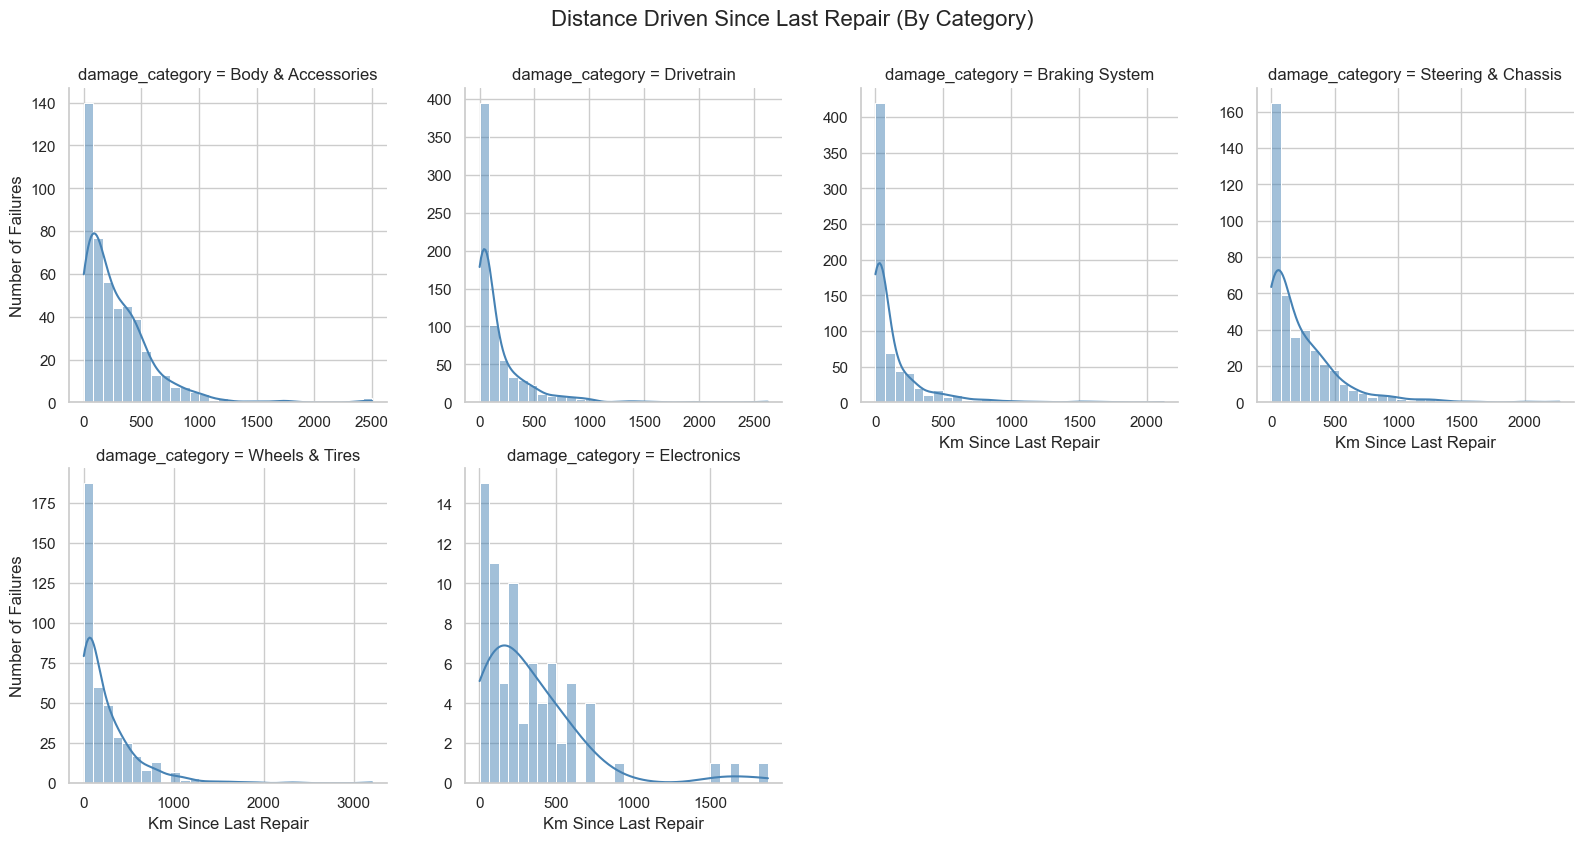

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style for the plots
sns.set_theme(style="whitegrid")

# Filter out the 'event_observed == 0' rows if you only want to look at ACTUAL broken parts
# (We don't want the artificially created survivors skewing our raw failure histograms)
actual_failures = damage_with_usage[damage_with_usage['event_observed'] == 1].copy()

# =====================================================================
# PLOT 1: The "Wear-and-Tear" Profile (Grid of Histograms)
# =====================================================================
g = sns.FacetGrid(actual_failures, col="damage_category", col_wrap=4, height=4, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x="km_since_last_failure", bins=30, color="steelblue", kde=True)
g.fig.suptitle('Distance Driven Since Last Repair (By Category)', y=1.05, fontsize=16)
g.set_axis_labels("Km Since Last Repair", "Number of Failures")
plt.show()

### The "Aging Fleet" Profile

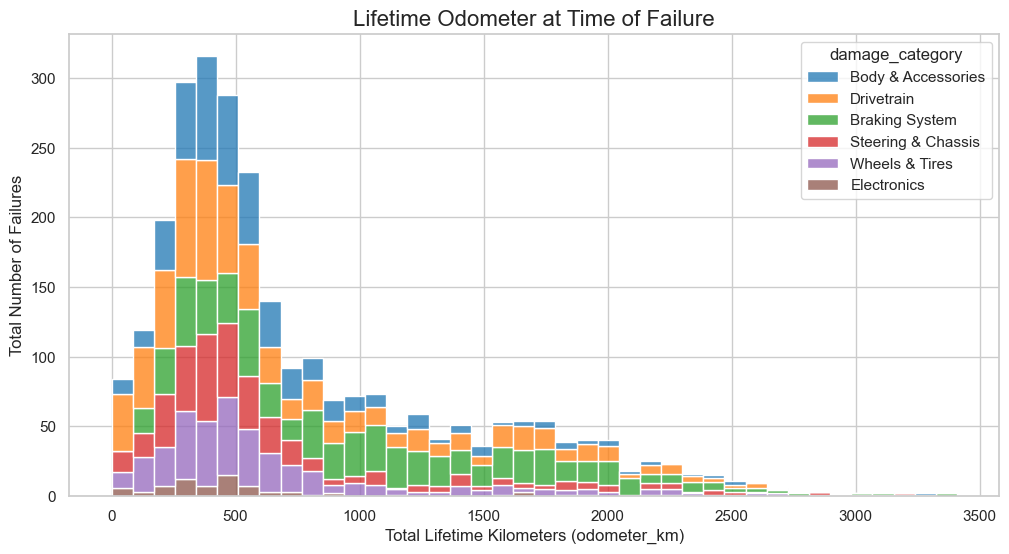

In [35]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=actual_failures, 
    x="odometer_km", 
    hue="damage_category", 
    multiple="stack", # Stacks the colors on top of each other
    bins=40,
    palette="tab10"
)
plt.title('Lifetime Odometer at Time of Failure', fontsize=16)
plt.xlabel('Total Lifetime Kilometers (odometer_km)')
plt.ylabel('Total Number of Failures')
plt.show()

### The "Operational Rhythm"

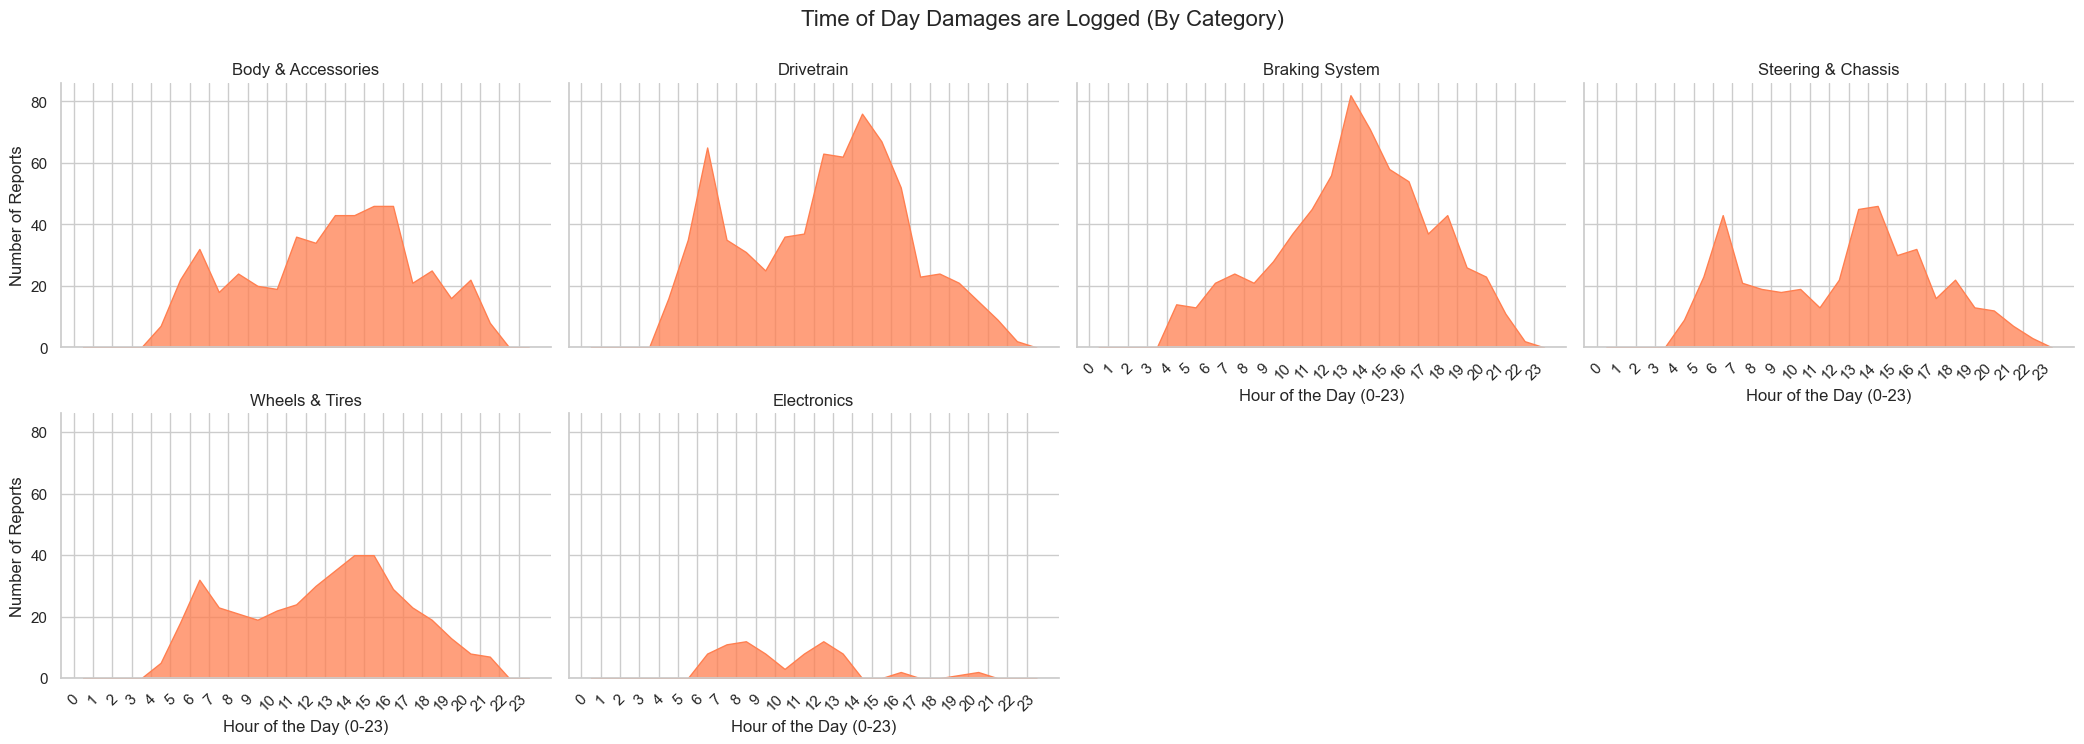

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set_theme(style="whitegrid")

# (Assuming actual_failures is already defined)

# =====================================================================
# PLOT 3: The "Operational Rhythm" (Separated by Category)
# =====================================================================
g = sns.displot(
    data=actual_failures, 
    x="created_hour", 
    col="damage_category", 
    col_wrap=4,           # Puts 4 plots on each row
    kind="hist", 
    element="poly",       # Keeps your preferred polygon style
    bins=24,
    binrange=(0, 24),     # Forces the x-axis to cover exactly 0 to 24 hours
    height=3.5,           # Made slightly taller for better visibility
    aspect=1.5,           # Width-to-height ratio of subplots
    color="coral"         
)

# Formatting the overall figure
g.fig.suptitle('Time of Day Damages are Logged (By Category)', y=1.05, fontsize=16)
g.set_axis_labels("Hour of the Day (0-23)", "Number of Reports")

# Force x-axis to show EVERY single hour
g.set(xticks=range(0, 24))

# Rotate the x-axis labels slightly so the 24 numbers don't overlap
for ax in g.axes.flat:
    ax.tick_params(axis='x', labelrotation=45)

# Clean up subplot titles
g.set_titles(col_template="{col_name}")

plt.show()

### The "Cycle-Wear" Profile

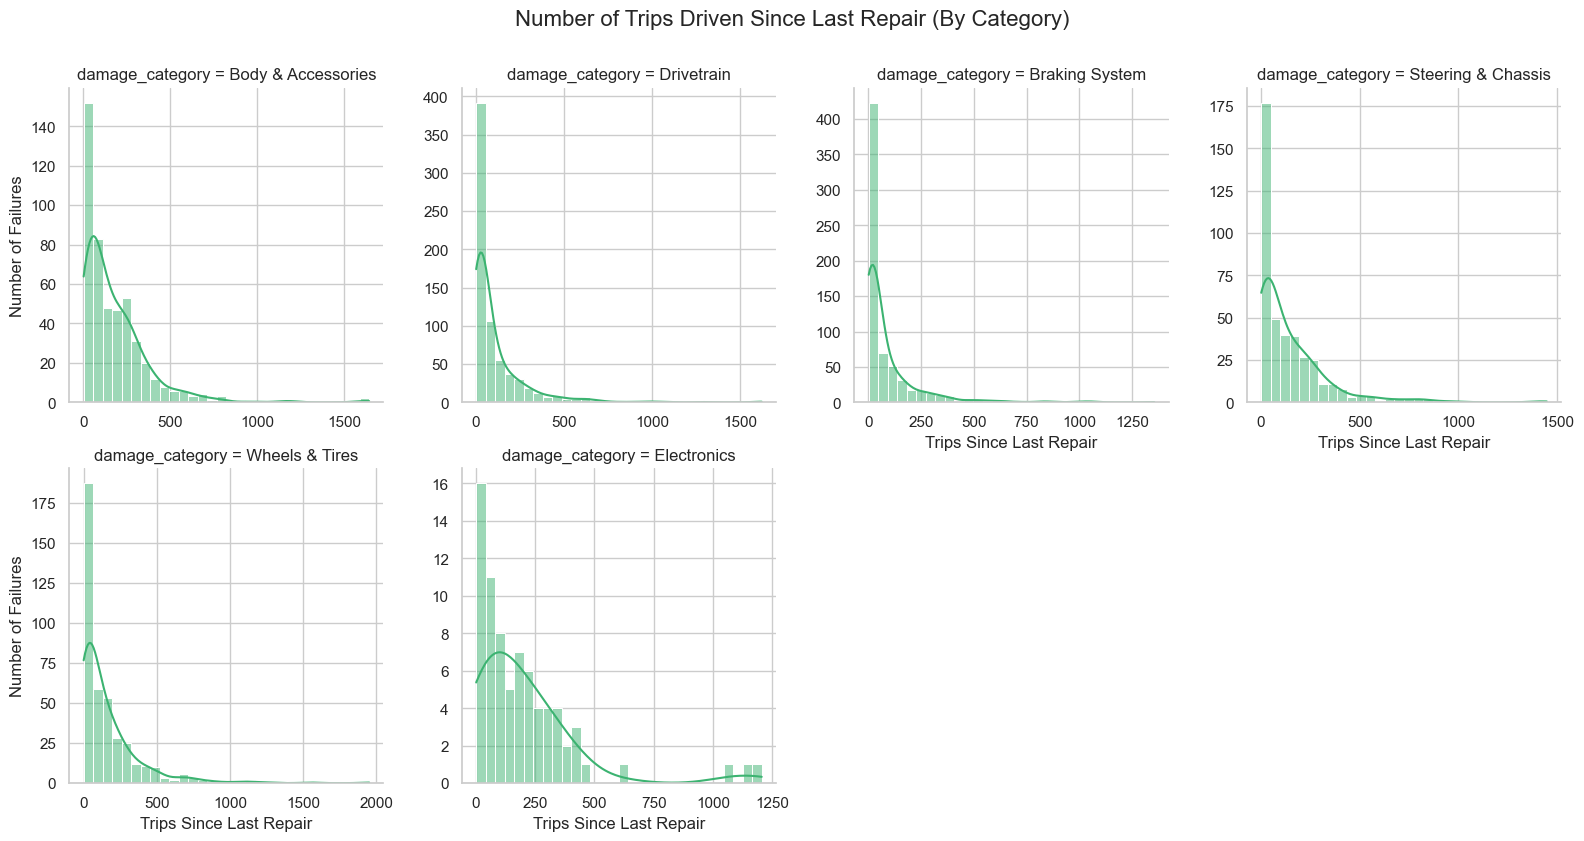

In [37]:
g = sns.FacetGrid(actual_failures, col="damage_category", col_wrap=4, height=4, sharex=False, sharey=False)

# Using a distinct color (mediumseagreen) so you don't confuse it with the distance plots!
g.map_dataframe(sns.histplot, x="trips_since_last_failure", bins=30, color="mediumseagreen", kde=True)

g.fig.suptitle('Number of Trips Driven Since Last Repair (By Category)', y=1.05, fontsize=16)
g.set_axis_labels("Trips Since Last Repair", "Number of Failures")

## Adding in surviving parts

Adding back in surviving parts for the Weibull dstribution to not exclude parts with longer lifelines from the calcultionof mean time to failure and median survival times
In damage_with_usage, each row corresponds to damages, but in the final_weibull_data we add back in the healthy part of the fleet

In [38]:
"""# ==============================================================================
# NEW CODE GOES HERE: ADDING RIGHT-CENSORED (SURVIVOR) DATA
# ==============================================================================

print("\n" + "="*60)
print("GENERATING RIGHT-CENSORED (SURVIVOR) DATA")
print("="*60)

# 1. Mark existing failures as events (1 = failure observed)
#damage_with_usage['event_observed'] = 1

# 2. Get the current max odometer reading for EVERY vehicle from usage_ref
current_fleet_status = usage_ref.groupby('vehicle_id')['odometer_km'].max()

survivor_rows_list = []
unique_categories = damage_with_usage['damage_category'].unique()

for category in unique_categories:
    
    # Get the vehicles that have had a failure in this specific category
    cat_failures = damage_with_usage[damage_with_usage['damage_category'] == category]
    
    # --- GROUP A: Vehicles that HAVE failed in this category before ---
    # Find distance driven SINCE their last failure up to their current max odometer
    last_failure_odo = cat_failures.groupby('vehicle_id')['odometer_km'].max()
    common_vehicles = last_failure_odo.index.intersection(current_fleet_status.index)
    dist_since_last = current_fleet_status.loc[common_vehicles] - last_failure_odo.loc[common_vehicles]
    
    survivors_A = pd.DataFrame({
        'vehicle_id': dist_since_last.index,
        'damage_category': category,
        'km_since_last_failure': dist_since_last.values,
        'event_observed': 0  # 0 = censored (survived without failure)
    })
    
    # --- GROUP B: Vehicles that have NEVER failed in this category ---
    # Find distance driven from 0 up to their current max odometer
    never_failed_ids = current_fleet_status.index.difference(last_failure_odo.index)
    survivors_B = pd.DataFrame({
        'vehicle_id': never_failed_ids,
        'damage_category': category,
        'km_since_last_failure': current_fleet_status.loc[never_failed_ids].values,
        'event_observed': 0
    })
    
    survivor_rows_list.extend([survivors_A, survivors_B])

# 3. Combine survivors
survivors_df = pd.concat(survivor_rows_list, ignore_index=True)
# Filter out 0km survivors to avoid math errors in Weibull
survivors_df = survivors_df[survivors_df['km_since_last_failure'] > 0].copy()

# 4. Create the FINAL dataset combining failures and survivors
final_weibull_data = pd.concat([
    damage_with_usage[['damage_category', 'km_since_last_failure', 'event_observed']],
    survivors_df[['damage_category', 'km_since_last_failure', 'event_observed']]
], ignore_index=True)

print(f"Original Failures: {len(damage_with_usage):,}")
print(f"Added Survivors:   {len(survivors_df):,} (Right Censored)")
print(f"Total Datapoints:  {len(final_weibull_data):,}")"""

"""# ==============================================================================
# UPDATED SURVIVOR GENERATION: 2023-2024 LOOKBACK
# ==============================================================================

print("\n" + "="*60)
print("GENERATING RIGHT-CENSORED (SURVIVOR) DATA")
print("="*60)

# 1. Get current max odometer for EVERY vehicle (the "End of the Story" point)
current_fleet_status = usage_ref.groupby('vehicle_id')['odometer_km'].max()
MIN_SURVIVOR_KM = 50.0
mechanical_categories = ['Braking System', 'Drivetrain', 'Wheels & Tires', 'Steering & Chassis']

survivor_rows_list = []

# Use categories from the mapped damage_data
unique_categories = [c for c in damage_data['damage_category'].unique() 
                     if c not in ['Too many quick returns', 'Unauthorized Trip', 'Unresponsive Controller', 'Vandalism', 'Electronics', 'Locking System']]

for category in unique_categories:
    
    # --- CRITICAL CHANGE ---
    # We look at ALL history (2023+2024) to find the absolute last failure.
    # We use 'damage_data' here because 'damage_with_usage' was filtered to 2024 only.
    cat_history = damage_data[damage_data['damage_category'] == category]
    
    # Get the last known odometer reading for a failure in this category per bike
    last_failure_odo = cat_history.groupby('vehicle_id')['odometer_km'].max()
    
    # --- GROUP A: Vehicles that HAVE failed in this category (in 2023 or 2024) ---
    # We calculate distance from their LAST repair ever recorded up to today.
    common_vehicles = last_failure_odo.index.intersection(current_fleet_status.index)
    dist_since_last = current_fleet_status.loc[common_vehicles] - last_failure_odo.loc[common_vehicles]
    
    survivors_A = pd.DataFrame({
        'vehicle_id': dist_since_last.index,
        'damage_category': category,
        'km_since_last_failure': dist_since_last.values,
        'event_observed': 0  # Still surviving
    })
    
    # --- GROUP B: Vehicles that have NEVER failed in this category (since Jan 2023) ---
    # These are bikes that exist in the fleet but never appeared in 'cat_history'
    never_failed_ids = current_fleet_status.index.difference(last_failure_odo.index)
    
    survivors_B = pd.DataFrame({
        'vehicle_id': never_failed_ids,
        'damage_category': category,
        'km_since_last_failure': current_fleet_status.loc[never_failed_ids].values,
        'event_observed': 0
    })
    
    survivor_rows_list.extend([survivors_A, survivors_B])

# 3. Combine survivors
survivors_df = pd.concat(survivor_rows_list, ignore_index=True)

# Filter out 0km survivors to avoid math errors
survivors_df = survivors_df[survivors_df['km_since_last_failure'] > 0].copy()

# 4. Create the FINAL dataset
# Combine the 2024 failures with these properly calculated survivors
final_weibull_data = pd.concat([
    damage_with_usage[['damage_category', 'km_since_last_failure', 'event_observed']],
    survivors_df[['damage_category', 'km_since_last_failure', 'event_observed']]
], ignore_index=True)

print(f"2024 Observed Failures: {len(damage_with_usage):,}")
print(f"Added Survivors:        {len(survivors_df):,} (Lookback 2023-2024)")
print(f"Total Combined Points:  {len(final_weibull_data):,}")"""


from lifelines import WeibullFitter, ExponentialFitter
import matplotlib.pyplot as plt
from tabulate import tabulate

# ==============================================================================
# 1. REFINED SURVIVOR GENERATION: 2023-2024 LOOKBACK & ELIGIBILITY
# ==============================================================================
print("\n" + "="*60)
print("GENERATING RIGHT-CENSORED (SURVIVOR) DATA")
print("="*60)

# Constants for Physical Realism
MIN_SURVIVOR_KM = 50.0
MECHANICAL_CATEGORIES = ['Braking System', 'Drivetrain', 'Wheels & Tires', 'Steering & Chassis']

damage_with_usage['event_observed'] = 1

# Get the "End of the Story" point for every vehicle in the fleet
current_fleet_status = usage_ref.groupby('vehicle_id')['odometer_km'].max()

survivor_rows_list = []

# Filter out categories that are not suitable for usage-based degradation modeling
unique_categories = [c for c in damage_data['damage_category'].unique() 
                    if c not in ['Too many quick returns', 'Unauthorized Trip', 
                                 'Unresponsive Controller', 'Vandalism', 
                                 'Logic/User Error', 'Security Flag', 'External Factor']]

for category in unique_categories:
    # Use ALL history (2023+2024) to find the absolute last failure point
    cat_history = damage_data[damage_data['damage_category'] == category]
    last_failure_odo = cat_history.groupby('vehicle_id')['odometer_km'].max()
    
    # --- GROUP A: Vehicles that HAVE failed in this category (2023-2024) ---
    # We calculate the distance survived from their LAST repair until today.
    common_vehicles = last_failure_odo.index.intersection(current_fleet_status.index)
    dist_since_last = current_fleet_status.loc[common_vehicles] - last_failure_odo.loc[common_vehicles]
    
    survivors_A = pd.DataFrame({
        'vehicle_id': dist_since_last.index,
        'damage_category': category,
        'km_since_last_failure': dist_since_last.values,
        'event_observed': 0  # Still functioning
    })
    
    # --- GROUP B: Vehicles that have NEVER failed in this category ---
    # We only include these as survivors if they have passed a minimum usage threshold
    never_failed_ids = current_fleet_status.index.difference(last_failure_odo.index)
    eligible_never_failed = current_fleet_status.loc[never_failed_ids]
    eligible_never_failed = eligible_never_failed[eligible_never_failed >= MIN_SURVIVOR_KM]
    
    survivors_B = pd.DataFrame({
        'vehicle_id': eligible_never_failed.index,
        'damage_category': category,
        'km_since_last_failure': eligible_never_failed.values,
        'event_observed': 0
    })
    
    survivor_rows_list.extend([survivors_A, survivors_B])

# Combine 2024 observed failures with these longitudinal survivors
survivors_df = pd.concat(survivor_rows_list, ignore_index=True)
survivors_df = survivors_df[survivors_df['km_since_last_failure'] > 0].copy()

final_weibull_data = pd.concat([
    damage_with_usage[['damage_category', 'km_since_last_failure', 'event_observed']],
    survivors_df[['damage_category', 'km_since_last_failure', 'event_observed']]
], ignore_index=True)

print(f"2024 Observed Failures: {len(damage_with_usage):,}")
print(f"Added Survivors:        {len(survivors_df):,} (Eligibility > {MIN_SURVIVOR_KM}km)")
print(f"Total Combined Points:  {len(final_weibull_data):,}")

'''# ==============================================================================
# REFINED SURVIVOR GENERATION: WITH TRIPS AND TRIP DENSITY (AFT COVARIATE)
# ==============================================================================
print("\n" + "="*60)
print("GENERATING RIGHT-CENSORED (SURVIVOR) DATA WITH TRIP COVARIATES")
print("="*60)

MIN_SURVIVOR_KM = 50.0

# Get BOTH max km and max trips for every vehicle
current_fleet_usage = usage_ref.groupby('vehicle_id').agg(
    max_km=('odometer_km', 'max'),
    max_trips=('lifetime_trip_count', 'max')
)

survivor_rows_list = []
unique_categories = [c for c in damage_data['damage_category'].unique() 
                     if c not in ['Too many quick returns', 'Unauthorized Trip', 
                                  'Unresponsive Controller', 'Vandalism', 
                                  'Logic/User Error', 'Security Flag', 'External Factor']]

for category in unique_categories:
    cat_history = damage_data[damage_data['damage_category'] == category]
    
    # We need the last km AND the last trip count when it failed
    last_failure_stats = cat_history.groupby('vehicle_id').agg(
        last_km=('odometer_km', 'max'),
        last_trips=('lifetime_trip_count', 'max') # Ensure this column exists in damage_data!
    )
    
    # --- GROUP A: Recurrent Survivors ---
    common_vehicles = last_failure_stats.index.intersection(current_fleet_usage.index)
    dist_since_last = current_fleet_usage.loc[common_vehicles, 'max_km'] - last_failure_stats.loc[common_vehicles, 'last_km']
    trips_since_last = current_fleet_usage.loc[common_vehicles, 'max_trips'] - last_failure_stats.loc[common_vehicles, 'last_trips']
    
    survivors_A = pd.DataFrame({
        'vehicle_id': dist_since_last.index,
        'damage_category': category,
        'km_since_last_failure': dist_since_last.values,
        'trips_since_last_failure': trips_since_last.values,
        'event_observed': 0 
    })
    survivors_A['trips_per_km'] = survivors_A['trips_since_last_failure'] / (survivors_A['km_since_last_failure'] + 0.001)
    
    # --- GROUP B: Absolute Survivors ---
    never_failed_ids = current_fleet_usage.index.difference(last_failure_stats.index)
    eligible_never_failed = current_fleet_usage.loc[never_failed_ids]
    eligible_never_failed = eligible_never_failed[eligible_never_failed['max_km'] >= MIN_SURVIVOR_KM]
    
    survivors_B = pd.DataFrame({
        'vehicle_id': eligible_never_failed.index,
        'damage_category': category,
        'km_since_last_failure': eligible_never_failed['max_km'].values,
        'trips_since_last_failure': eligible_never_failed['max_trips'].values,
        'event_observed': 0
    })
    survivors_B['trips_per_km'] = survivors_B['trips_since_last_failure'] / (survivors_B['km_since_last_failure'] + 0.001)
    
    survivor_rows_list.extend([survivors_A, survivors_B])



survivors_df = pd.concat(survivor_rows_list, ignore_index=True)
survivors_df = survivors_df[survivors_df['km_since_last_failure'] > 0].copy()

damage_with_usage['event_observed'] = 1

# Combine everything into the final dataset
final_weibull_data = pd.concat([
    damage_with_usage[['damage_category', 'km_since_last_failure', 'trips_per_km', 'event_observed']],
    survivors_df[['damage_category', 'km_since_last_failure', 'trips_per_km', 'event_observed']]
], ignore_index=True)

print(f"Data ready for AFT Model! Total Combined Points: {len(final_weibull_data):,}")'''




GENERATING RIGHT-CENSORED (SURVIVOR) DATA
2024 Observed Failures: 3,847
Added Survivors:        4,566 (Eligibility > 50.0km)
Total Combined Points:  8,413


'# ==============================================================================\n# REFINED SURVIVOR GENERATION: WITH TRIPS AND TRIP DENSITY (AFT COVARIATE)\n# ==============================================================================\nprint("\n" + "="*60)\nprint("GENERATING RIGHT-CENSORED (SURVIVOR) DATA WITH TRIP COVARIATES")\nprint("="*60)\n\nMIN_SURVIVOR_KM = 50.0\n\n# Get BOTH max km and max trips for every vehicle\ncurrent_fleet_usage = usage_ref.groupby(\'vehicle_id\').agg(\n    max_km=(\'odometer_km\', \'max\'),\n    max_trips=(\'lifetime_trip_count\', \'max\')\n)\n\nsurvivor_rows_list = []\nunique_categories = [c for c in damage_data[\'damage_category\'].unique() \n                     if c not in [\'Too many quick returns\', \'Unauthorized Trip\', \n                                  \'Unresponsive Controller\', \'Vandalism\', \n                                  \'Logic/User Error\', \'Security Flag\', \'External Factor\']]\n\nfor category in unique_categories:\n    cat_h

# Fit Weibull distribution

## Comparison of old and new weibull distribution

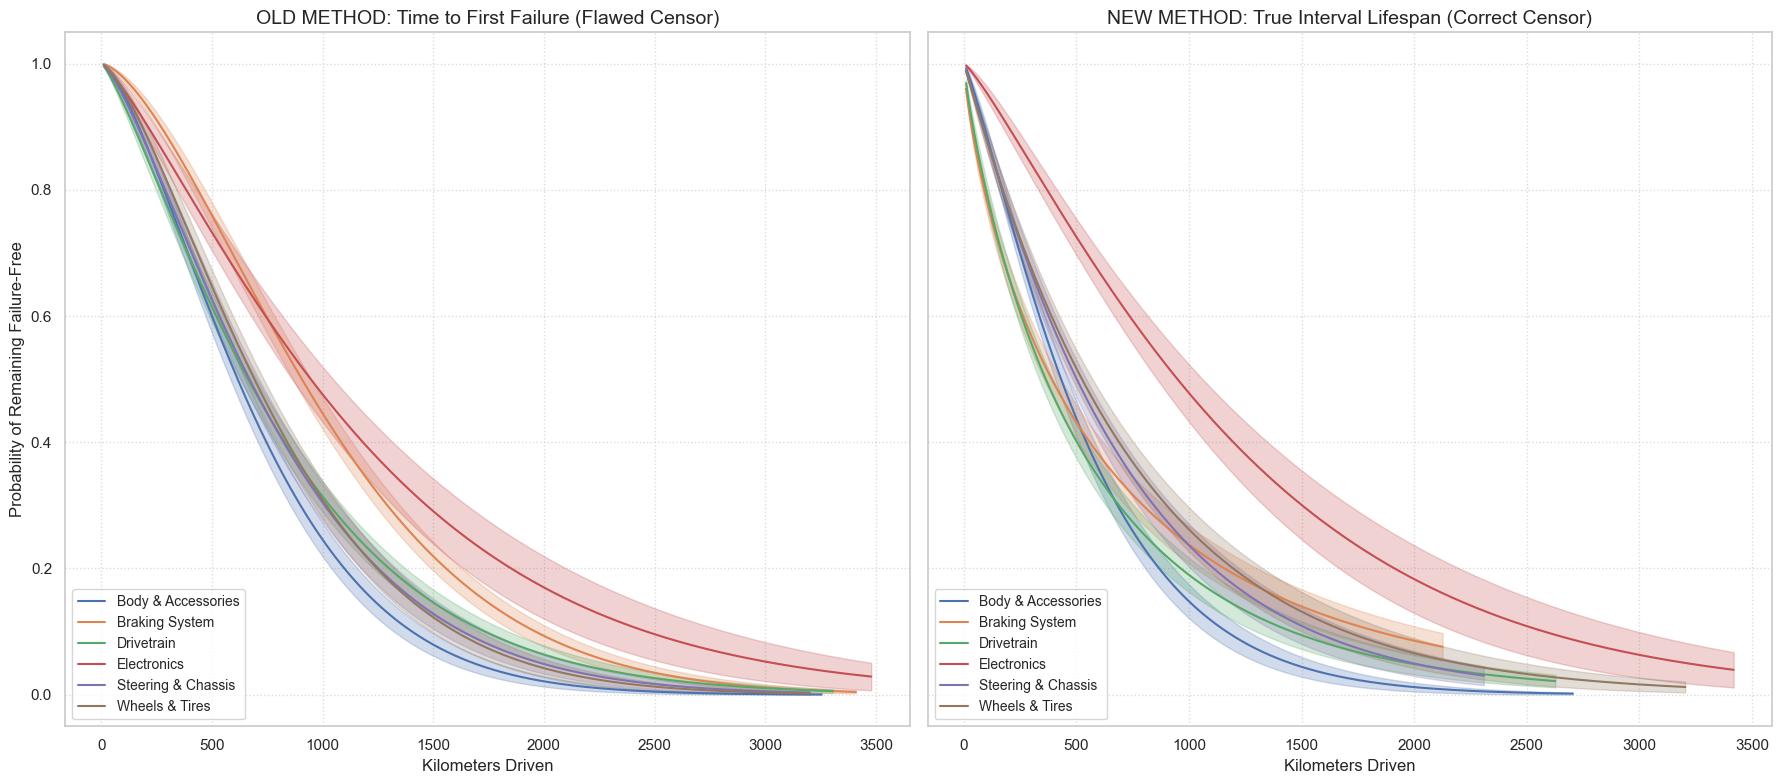


                       SIMULATOR METRICS: OLD VS NEW AVERAGE LIFESPANS (MEDIAN & MTTF)                        
+--------------------+---------+--------------+------------+---------+--------------+------------+---------------+
| Category           |   Old N |   Old Median |   Old MTTF |   New N |   New Median |   New MTTF |   Diff (MTTF) |
|--------------------+---------+--------------+------------+---------+--------------+------------+---------------|
| Body & Accessories |     986 |        616.1 |      717.9 |    1256 |        432.3 |      549.5 |        -168.4 |
| Drivetrain         |    1242 |        662.8 |      827.8 |    1333 |        364.2 |      598.3 |        -229.6 |
| Steering & Chassis |     992 |        669.5 |      806.4 |    1169 |        501.8 |      692.4 |        -114.0 |
| Braking System     |    1281 |        906.1 |     1031.3 |    1336 |        390.5 |      726.6 |        -304.6 |
| Wheels & Tires     |     976 |        691.6 |      811.6 |    1131 |        524.7

In [39]:
import math
import pandas as pd
import numpy as np
from lifelines import WeibullFitter
import matplotlib.pyplot as plt
from tabulate import tabulate

# 1. Setup Data & Plots
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

old_weibull_results = []
new_weibull_results = []

fleet_max_km = usage_ref.groupby('vehicle_id')['odometer_km'].max()
categories = [c for c in damage_with_usage['damage_category'].unique() 
              if c not in ['Other', 'Logic/User Error', 'Security Flag', 'External Factor']]

# 2. Loop Through Categories for Both Methods
for cat_name in categories:
    
    # =========================================================
    # METHOD 1: THE OLD WAY (From your original code)
    # =========================================================
    cat_failures_old = damage_with_usage[damage_with_usage['damage_category'] == cat_name].copy()
    cat_failures_old['age_at_failure'] = cat_failures_old['odometer_km']
    cat_failures_old = cat_failures_old[cat_failures_old['age_at_failure'] > 10.0]
    
    if len(cat_failures_old) >= 5:
        df_failures_old = pd.DataFrame({'km': cat_failures_old['age_at_failure'], 'event': 1})
        
        # Only grabs Group B (never failed)
        failed_vehicles = set(cat_failures_old['vehicle_id'].unique())
        censored_vehicles = set(fleet_max_km.index) - failed_vehicles
        df_censored_old = pd.DataFrame({'km': fleet_max_km[list(censored_vehicles)].values, 'event': 0})
        df_censored_old = df_censored_old[df_censored_old['km'] > 10.0]
        
        df_fit_old = pd.concat([df_failures_old, df_censored_old])
        
        wf_old = WeibullFitter()
        try:
            wf_old.fit(df_fit_old['km'], event_observed=df_fit_old['event'], label=cat_name)
            wf_old.plot_survival_function(ax=axes[0])
            old_weibull_results.append({
                'Category': cat_name,
                'Old_Shape': wf_old.rho_,
                'Old_Scale': wf_old.lambda_,
                'Old_Data_Points': len(df_fit_old)
            })
        except Exception:
            pass

    # =========================================================
    # METHOD 2: THE NEW WAY (Using final_weibull_data)
    # =========================================================
    df_new = final_weibull_data[final_weibull_data['damage_category'] == cat_name].copy()
    
    # Filter noise to match the old logic
    df_new = df_new[df_new['km_since_last_failure'] > 10.0]
    
    # Check if we have enough actual failure events (1s) to fit a curve
    if len(df_new[df_new['event_observed'] == 1]) >= 5:
        wf_new = WeibullFitter()
        try:
            wf_new.fit(df_new['km_since_last_failure'], event_observed=df_new['event_observed'], label=cat_name)
            wf_new.plot_survival_function(ax=axes[1])
            new_weibull_results.append({
                'Category': cat_name,
                'New_Shape': wf_new.rho_,
                'New_Scale': wf_new.lambda_,
                'New_Data_Points': len(df_new)
            })
        except Exception:
            pass

# 3. Format Plots
axes[0].set_title('OLD METHOD: Time to First Failure (Flawed Censor)', fontsize=14)
axes[1].set_title('NEW METHOD: True Interval Lifespan (Correct Censor)', fontsize=14)

for ax in axes:
    ax.set_xlabel('Kilometers Driven')
    ax.set_ylabel('Probability of Remaining Failure-Free')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='lower left', fontsize='small')

plt.tight_layout()
plt.show()

# 4. Calculate Median (B50) Life and MTTF and Compare
df_old = pd.DataFrame(old_weibull_results)
if not df_old.empty:
    # Median Life (B50)
    df_old['Old_Median_km'] = df_old.apply(
        lambda r: r['Old_Scale'] * ((-math.log(0.50))**(1/r['Old_Shape'])), axis=1
    )
    # Mean Time To Failure (MTTF)
    df_old['Old_MTTF_km'] = df_old.apply(
        lambda r: r['Old_Scale'] * math.gamma(1 + (1/r['Old_Shape'])), axis=1
    )

df_new = pd.DataFrame(new_weibull_results)
if not df_new.empty:
    # Median Life (B50)
    df_new['New_Median_km'] = df_new.apply(
        lambda r: r['New_Scale'] * ((-math.log(0.50))**(1/r['New_Shape'])), axis=1
    )
    # Mean Time To Failure (MTTF)
    df_new['New_MTTF_km'] = df_new.apply(
        lambda r: r['New_Scale'] * math.gamma(1 + (1/r['New_Shape'])), axis=1
    )

# Merge tables for a clean side-by-side comparison
if not df_old.empty and not df_new.empty:
    comparison_df = pd.merge(
        df_old[['Category', 'Old_Data_Points', 'Old_Median_km', 'Old_MTTF_km']], 
        df_new[['Category', 'New_Data_Points', 'New_Median_km', 'New_MTTF_km']], 
        on='Category', 
        how='inner'
    )
    
    # Calculate how much the calculation improved
    comparison_df['Diff_MTTF_km'] = comparison_df['New_MTTF_km'] - comparison_df['Old_MTTF_km']
    comparison_df = comparison_df.sort_values('New_MTTF_km')
    
    print("\n" + "="*110)
    print(f"{'SIMULATOR METRICS: OLD VS NEW AVERAGE LIFESPANS (MEDIAN & MTTF)':^110}")
    print("="*110)
    
    display_headers = [
        'Category', 'Old N', 'Old Median', 'Old MTTF', 
        'New N', 'New Median', 'New MTTF', 'Diff (MTTF)'
    ]
    
    print(tabulate(
        comparison_df, 
        headers=display_headers, 
        tablefmt='psql', 
        showindex=False, 
        floatfmt=".1f"
    ))

## Weibull fitter with survivors

(ADDING IN SURVIVORS)
This formulation uses the lifeline python package for calculating and plotting the Probability Density Function (PDF)

### Using libary for PDF calculation

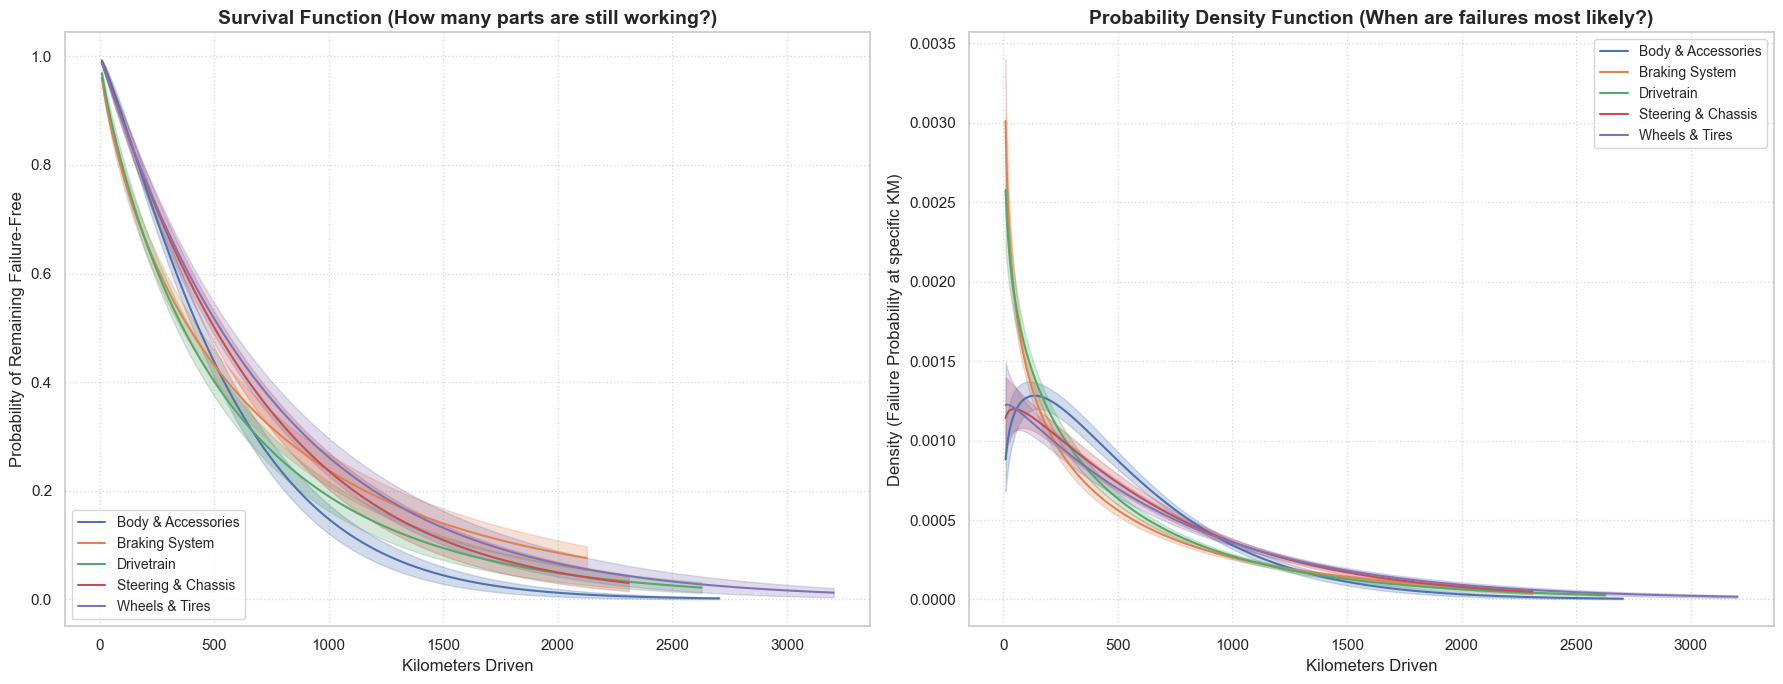


                             SIMULATOR METRICS: AVERAGE LIFESPANS (MEDIAN & MTTF)                             
COLUMN EXPLANATIONS:
- Category:        The specific physical component or system on the bike being analyzed.
- Shape (ρ):       Dictates how it fails; > 1 means it wears out over time, ~1 means failures are random.
- Scale (λ):       The curve's 'characteristic life' where approximately 63.2% of these parts will have failed.
- Data Points (N): The total number of observed failures AND working survivors in the model.
- Median (km):     The exact distance at which 50% of the parts are expected to have failed.
- MTTF (km):       The Mean Time To Failure (True mathematical average lifespan).
--------------------------------------------------------------------------------------------------------------
+--------------------+-------------+-------------+-------------------+---------------+-------------+
| Category           |   Shape (ρ) |   Scale (λ) |   Data Points (N) |   Median 

In [40]:
# THIS IS ONLY THE NEW METHOD (USING THE DATA SET WITH THE ADDED SURVIVORS)
import math
import pandas as pd
import numpy as np
from lifelines import WeibullFitter
import matplotlib.pyplot as plt
from tabulate import tabulate

# 1. Setup Data & Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) 

weibull_results = []

# Filtering out logic/external categories for the reliability study
categories = [c for c in damage_with_usage['damage_category'].unique() 
              if c not in ['Too many quick returns', 'Unauthorized Trip', 'Unresponsive Controller', 'Vandalism', 'Electronics', 'Locking System']]

# 2. Loop Through Categories
for cat_name in categories:
    
    # Extract the corrected, right-censored dataset
    df_fit = final_weibull_data[final_weibull_data['damage_category'] == cat_name].copy()
    
    # Filter noise (e.g., immediate duplicate logs)
    df_fit = df_fit[df_fit['km_since_last_failure'] > 10.0]
    
    # Check if we have enough actual failure events (1s) to fit a reliable curve
    if len(df_fit[df_fit['event_observed'] == 1]) >= 5:
        wf = WeibullFitter()
        try:
            # Fitting to 'km_since_last_failure' is the "True Interval" method
            wf.fit(df_fit['km_since_last_failure'], event_observed=df_fit['event_observed'], label=cat_name)
        
            # Plot 1: Survival on the left (axes[0])
            wf.plot_survival_function(ax=axes[0])
            
            # Plot 2: Probability Density (PDF) on the right (axes[1])
            # .plot_density() is the lifelines built-in for the PDF/Bell Curve
            wf.plot_density(ax=axes[1])
            
            # Store the parameters for the simulator
            weibull_results.append({
                'Category': cat_name,
                'Shape (ρ)': wf.rho_,
                'Scale (λ)': wf.lambda_,
                'Data Points (N)': len(df_fit)
            })
        except Exception as e:
            print(f"Skipping {cat_name}: {e}")

# --- Format Plots ---
axes[0].set_title('Survival Function (How many parts are still working?)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kilometers Driven')
axes[0].set_ylabel('Probability of Remaining Failure-Free')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='lower left', fontsize='small')

axes[1].set_title('Probability Density Function (When are failures most likely?)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kilometers Driven')
axes[1].set_ylabel('Density (Failure Probability at specific KM)')
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

# 4. Calculate Median (B50) Life and MTTF
df_results = pd.DataFrame(weibull_results)

if not df_results.empty:
    # Median Life (B50)
    df_results['Median (km)'] = df_results.apply(
        lambda r: r['Scale (λ)'] * ((-math.log(0.50))**(1/r['Shape (ρ)'])), axis=1
    )
    # Mean Time To Failure (MTTF)
    df_results['MTTF (km)'] = df_results.apply(
        lambda r: r['Scale (λ)'] * math.gamma(1 + (1/r['Shape (ρ)'])), axis=1
    )

    # Sort by the average lifespan for logical reading
    df_results = df_results.sort_values('MTTF (km)')
    
    # --- FINAL PROFESSIONAL PRINTOUT ---
    print("\n" + "="*110)
    print(f"{'SIMULATOR METRICS: AVERAGE LIFESPANS (MEDIAN & MTTF)':^110}")
    print("="*110)
    print("COLUMN EXPLANATIONS:")
    print("- Category:        The specific physical component or system on the bike being analyzed.")
    print("- Shape (ρ):       Dictates how it fails; > 1 means it wears out over time, ~1 means failures are random.")
    print("- Scale (λ):       The curve's 'characteristic life' where approximately 63.2% of these parts will have failed.")
    print("- Data Points (N): The total number of observed failures AND working survivors in the model.")
    print("- Median (km):     The exact distance at which 50% of the parts are expected to have failed.")
    print("- MTTF (km):       The Mean Time To Failure (True mathematical average lifespan).")
    print("-" * 110)
    
    print(tabulate(
        df_results, 
        headers='keys', 
        tablefmt='psql', 
        showindex=False, 
        floatfmt=".2f"
    ))
    print("-" * 110)

### Manual PDF calculation


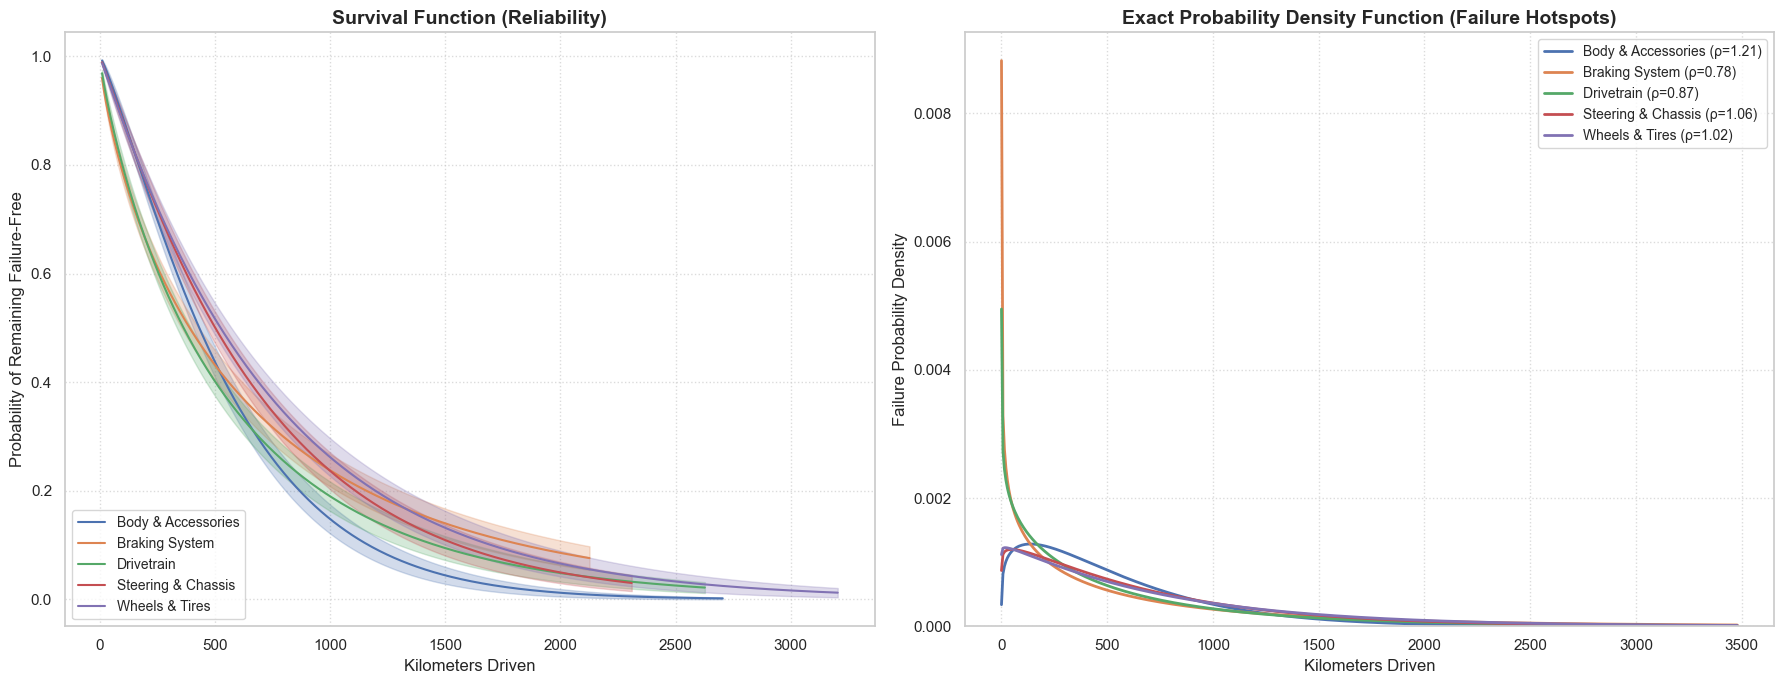


                             SIMULATOR METRICS: AVERAGE LIFESPANS (MEDIAN & MTTF)                             
+--------------------+-------------+-------------+-------------------+---------------+-------------+
| Category           |   Shape (ρ) |   Scale (λ) |   Data Points (N) |   Median (km) |   MTTF (km) |
|--------------------+-------------+-------------+-------------------+---------------+-------------|
| Body & Accessories |        1.21 |      585.32 |              1256 |        432.27 |      549.51 |
| Drivetrain         |        0.87 |      556.14 |              1333 |        364.20 |      598.27 |
| Steering & Chassis |        1.06 |      708.75 |              1169 |        501.79 |      692.40 |
| Braking System     |        0.78 |      626.52 |              1336 |        390.48 |      726.64 |
| Wheels & Tires     |        1.02 |      751.06 |              1131 |        524.72 |      744.36 |
+--------------------+-------------+-------------+-------------------+----------

In [41]:
# THIS IS ONLY THE NEW METHOD (USING THE DATA SET WITH THE ADDED SURVIVORS)
import math
import pandas as pd
import numpy as np
from lifelines import WeibullFitter
import matplotlib.pyplot as plt
from tabulate import tabulate

# 1. Setup Data & Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7)) 

weibull_results = []

# Define x-range for the PDF plot (e.g., from 0 to 5000km)
x_max = final_weibull_data['km_since_last_failure'].max()
x_range = np.linspace(0.1, x_max, 500) # Start at 0.1 to avoid division by zero

# Filtering out logic/external categories for the reliability study
categories = [c for c in final_weibull_data['damage_category'].unique() 
              if c not in ['Too many quick returns', 'Unauthorized Trip', 'Unresponsive Controller', 'Vandalism', 'Electronics', 'Locking System']]

# 2. Loop Through Categories
for cat_name in categories:
    
    # Extract the corrected, right-censored dataset
    df_fit = final_weibull_data[final_weibull_data['damage_category'] == cat_name].copy()
    
    # Filter noise
    df_fit = df_fit[df_fit['km_since_last_failure'] > 10.0]
    
    if len(df_fit[df_fit['event_observed'] == 1]) >= 5:
        wf = WeibullFitter()
        try:
            wf.fit(df_fit['km_since_last_failure'], event_observed=df_fit['event_observed'], label=cat_name)
        
            # Plot 1: Survival on the left
            wf.plot_survival_function(ax=axes[0])
            
            # --- MANUAL PDF CALCULATION ---
            rho = wf.rho_
            lmbda = wf.lambda_
            
            # f(t) = (rho/lmbda) * (t/lmbda)**(rho-1) * exp(-(t/lmbda)**rho)
            pdf_values = (rho / lmbda) * (x_range / lmbda)**(rho - 1) * np.exp(-(x_range / lmbda)**rho)
            
            axes[1].plot(x_range, pdf_values, label=f"{cat_name} (ρ={rho:.2f})", lw=2)
            
            # Store the parameters
            weibull_results.append({
                'Category': cat_name,
                'Shape (ρ)': rho,
                'Scale (λ)': lmbda,
                'Data Points (N)': len(df_fit)
            })
        except Exception as e:
            print(f"Skipping {cat_name}: {e}")

# --- Format Plots ---
axes[0].set_title('Survival Function (Reliability)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kilometers Driven')
axes[0].set_ylabel('Probability of Remaining Failure-Free')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='lower left', fontsize='small')

axes[1].set_title('Exact Probability Density Function (Failure Hotspots)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kilometers Driven')
axes[1].set_ylabel('Failure Probability Density')
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='upper right', fontsize='small')
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

# 4. Final Reporting
df_results = pd.DataFrame(weibull_results)

if not df_results.empty:
    df_results['Median (km)'] = df_results.apply(
        lambda r: r['Scale (λ)'] * ((-math.log(0.50))**(1/r['Shape (ρ)'])), axis=1
    )
    df_results['MTTF (km)'] = df_results.apply(
        lambda r: r['Scale (λ)'] * math.gamma(1 + (1/r['Shape (ρ)'])), axis=1
    )

    df_results = df_results.sort_values('MTTF (km)')
    
    print("\n" + "="*110)
    print(f"{'SIMULATOR METRICS: AVERAGE LIFESPANS (MEDIAN & MTTF)':^110}")
    print("="*110)
    
    print(tabulate(
        df_results, 
        headers='keys', 
        tablefmt='psql', 
        showindex=False, 
        floatfmt=".2f"
    ))
    print("-" * 110)

### Capping rho at 1

⚠️ Braking System: Statistical rho=0.78 < 1.0. Correcting to rho=1.0
⚠️ Drivetrain: Statistical rho=0.87 < 1.0. Correcting to rho=1.0


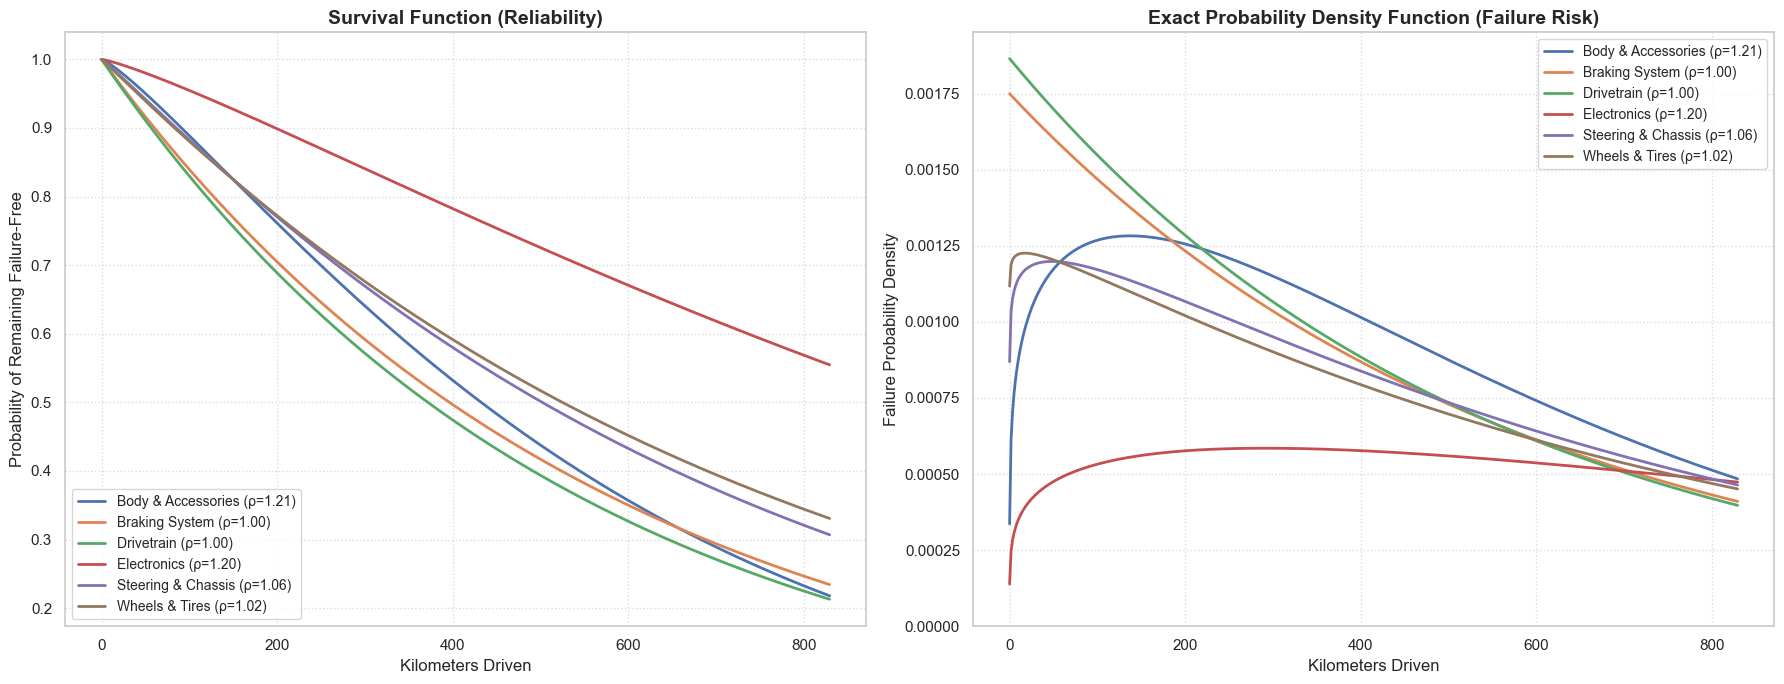

In [42]:
import math
import pandas as pd
import numpy as np
from lifelines import WeibullFitter, ExponentialFitter # <--- IMPORT EXPONENTIAL FITTER
import matplotlib.pyplot as plt
from tabulate import tabulate

fig, axes = plt.subplots(1, 2, figsize=(18, 7)) 

weibull_results = []
x_max = final_weibull_data['km_since_last_failure'].quantile(0.95)
x_range = np.linspace(0.1, x_max, 500)

for cat_name in unique_categories:
    df_fit = final_weibull_data[final_weibull_data['damage_category'] == cat_name].copy()
    df_fit = df_fit[df_fit['km_since_last_failure'] > 10.0]
    
    if len(df_fit[df_fit['event_observed'] == 1]) >= 5:
        wf = WeibullFitter()
        try:
            wf.fit(df_fit['km_since_last_failure'], event_observed=df_fit['event_observed'], label=cat_name)
            
            rho = wf.rho_
            lmbda = wf.lambda_
            
            # ==========================================================================
            # THE PHYSICAL REALISM GUARD
            # ==========================================================================
            # If the category is mechanical and the math suggests rho < 1,
            # we force rho to 1.0 (Exponential Distribution - Constant Failure Rate)
            if cat_name in MECHANICAL_CATEGORIES and rho < 1.0:
                print(f"⚠️ {cat_name}: Statistical rho={rho:.2f} < 1.0. Correcting to rho=1.0")
                ef = ExponentialFitter()
                ef.fit(df_fit['km_since_last_failure'], event_observed=df_fit['event_observed'])
                rho = 1.0
                lmbda = ef.lambda_
            # ==========================================================================
            
            # Calculate plotting values manually to reflect corrected parameters
            survival_values = np.exp(-(x_range / lmbda)**rho)
            pdf_values = (rho / lmbda) * (x_range / lmbda)**(rho - 1) * np.exp(-(x_range / lmbda)**rho)
            
            axes[0].plot(x_range, survival_values, label=f"{cat_name} (ρ={rho:.2f})", lw=2)
            axes[1].plot(x_range, pdf_values, label=f"{cat_name} (ρ={rho:.2f})", lw=2)
            
            weibull_results.append({
                'Category': cat_name,
                'Shape (ρ)': rho,
                'Scale (λ)': lmbda,
                'Data Points (N)': len(df_fit)
            })
        except Exception as e:
            print(f"Skipping {cat_name}: {e}")

axes[0].set_title('Survival Function (Reliability)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kilometers Driven')
axes[0].set_ylabel('Probability of Remaining Failure-Free')
axes[0].grid(True, linestyle=':', alpha=0.7)
axes[0].legend(loc='lower left', fontsize='small')

axes[1].set_title('Exact Probability Density Function (Failure Risk)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kilometers Driven')
axes[1].set_ylabel('Failure Probability Density')
axes[1].grid(True, linestyle=':', alpha=0.7)
axes[1].legend(loc='upper right', fontsize='small')
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

## OLD Weibull fitter

(NOT ADDING SURVIVORS)
This is not learning behavior from the parts that are working. Meaning the

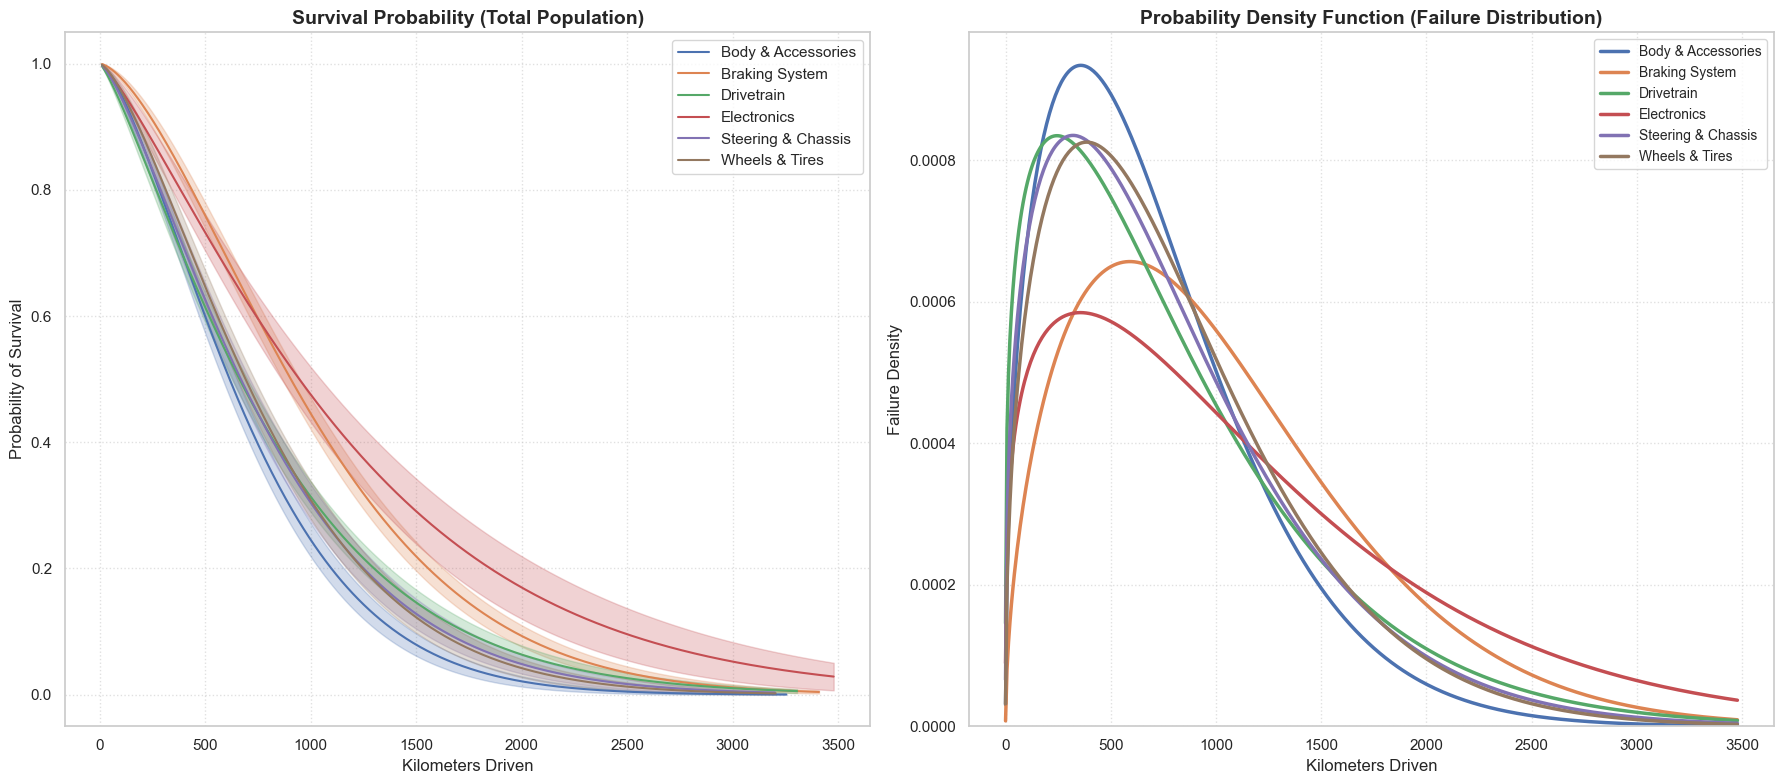


                             SIMULATOR METRICS: AVERAGE LIFESPANS (MEDIAN & MTTF)                             
COLUMN EXPLANATIONS:
- Category:        The specific physical component or system on the bike being analyzed.
- Shape (ρ):       Dictates how it fails; > 1 means it wears out over time, ~1 means failures are random.
- Scale (λ):       The curve's 'characteristic life' where % of parts will have failed.
- Data Points (N): Total count of observed failures AND working survivors used in calculation.
- Median (km):     The distance at which exactly 50% of the parts are expected to have failed.
- MTTF (km):       The Mean Time To Failure (mathematical average lifespan).
--------------------------------------------------------------------------------------------------------------
+--------------------+-------------+-------------+-------------------+---------------+-------------+
| Category           |   Shape (ρ) |   Scale (λ) |   Data Points (N) |   Median (km) |   MTTF (km) |
|---

In [43]:
import math
import pandas as pd
import numpy as np
from lifelines import WeibullFitter
import matplotlib.pyplot as plt
from tabulate import tabulate

# 1. Initialize Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

weibull_results = []
fleet_max_km = usage_ref.groupby('vehicle_id')['odometer_km'].max()
categories = [c for c in damage_with_usage['damage_category'].unique() 
              if c not in ['Too many quick returns', 'Unauthorized Trip', 'Unresponsive Controller', 'Vandalism']]

# Setup for PDF plotting (0 to 5000km or max odometer)
max_x = min(usage_ref['odometer_km'].max(), 5000)
x_range = np.linspace(0.1, max_x, 500)

for cat_name in categories:
    cat_failures = damage_with_usage[damage_with_usage['damage_category'] == cat_name].copy()
    cat_failures['age_at_failure'] = cat_failures['odometer_km']
    cat_failures = cat_failures[cat_failures['age_at_failure'] > 10.0]
    
    if len(cat_failures) < 5:
        continue

    df_failures = pd.DataFrame({'km': cat_failures['age_at_failure'], 'event': 1})
    failed_vehicles = set(cat_failures['vehicle_id'].unique())
    censored_vehicles = set(fleet_max_km.index) - failed_vehicles

    df_censored = pd.DataFrame({
        'km': fleet_max_km[list(censored_vehicles)].values,
        'event': 0
    })
    df_censored = df_censored[df_censored['km'] > 10.0]
    df_fit = pd.concat([df_failures, df_censored])

    wf = WeibullFitter()
    try:
        wf.fit(df_fit['km'], event_observed=df_fit['event'], label=cat_name)
        
        # --- PLOT 1: Survival Function ---
        wf.plot_survival_function(ax=ax1)
        
        # --- PLOT 2: Manual PDF Calculation ---
        rho = wf.rho_
        lmbda = wf.lambda_
        pdf_values = (rho/lmbda) * (x_range/lmbda)**(rho-1) * np.exp(-(x_range/lmbda)**rho)
        ax2.plot(x_range, pdf_values, label=cat_name, lw=2.5)

        # Calculate Statistics for the Report
        median = lmbda * (math.log(2)**(1/rho))
        mttf = lmbda * math.gamma(1 + (1/rho))
        
        weibull_results.append({
            'Category': cat_name,
            'Shape (ρ)': rho,
            'Scale (λ)': lmbda,
            'Data Points (N)': len(df_fit),
            'Median (km)': median,
            'MTTF (km)': mttf
        })

    except Exception as e:
        print(f"Skipping {cat_name}: {e}")

# --- Formatting the Visuals ---
ax1.set_title('Survival Probability (Total Population)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Kilometers Driven')
ax1.set_ylabel('Probability of Survival')
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.set_title('Probability Density Function (Failure Distribution)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Kilometers Driven')
ax2.set_ylabel('Failure Density')
ax2.set_ylim(bottom=0)
ax2.legend(loc='upper right', fontsize='small')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- 2. GENERATE THE PROFESSIONAL REPORT ---
results_df = pd.DataFrame(weibull_results)

if not results_df.empty:
    print("\n" + "="*110)
    print(f"{'SIMULATOR METRICS: AVERAGE LIFESPANS (MEDIAN & MTTF)':^110}")
    print("="*110)
    print("COLUMN EXPLANATIONS:")
    print("- Category:        The specific physical component or system on the bike being analyzed.")
    print("- Shape (ρ):       Dictates how it fails; > 1 means it wears out over time, ~1 means failures are random.")
    print("- Scale (λ):       The curve's 'characteristic life' where % of parts will have failed.")
    print("- Data Points (N): Total count of observed failures AND working survivors used in calculation.")
    print("- Median (km):     The distance at which exactly 50% of the parts are expected to have failed.")
    print("- MTTF (km):       The Mean Time To Failure (mathematical average lifespan).")
    print("-" * 110)

    # Sort by Median life to show most vulnerable parts first
    results_df = results_df.sort_values('Median (km)')

    print(tabulate(
        results_df, 
        headers='keys', 
        tablefmt='psql', 
        showindex=False, 
        floatfmt=".2f"
    ))
    print("-" * 110)

# Export config

In [44]:
def export_to_simulator_config(results, filename="damage_configuration.py"):
    """
    Automates the translation of lifelines Weibull results into the 
    Simulator's configuration format.
    """
    header = '"""\nWeibull distribution parameters for component failures\n'
    header += f'Automatically generated from maintenance data on {pd.Timestamp.now().strftime("%Y-%m-%d")}\n'
    header += '"""\n\nDAMAGE_CATEGORIES = {\n'
    
    body = ""
    for entry in results:
        body += f"    '{entry['Category']}': {{\n"
        body += f"        'shape': {entry['Shape (ρ)']:.4f},\n"
        body += f"        'scale': {entry['Scale (λ)']:.4f},\n"
        body += f"        'median_km': {entry['Median (km)']:.2f},\n"
        body += f"        'mttf_km': {entry['MTTF (km)']:.2f}\n"
        body += "    },\n"
    
    footer = "}\n"
    
    config_content = header + body + footer
    
    # Writing the file
    with open(filename, "w", encoding="utf-8") as f:
        f.write(config_content)
    
    print(f"\n[SUCCESS] Configuration exported to {os.path.abspath(filename)}")
    print("Verify the parameters before running the simulator.")

# Execute the export
if weibull_results:
    export_to_simulator_config(weibull_results)


[SUCCESS] Configuration exported to c:\Users\Minamsj\FOMOsim\policies\sjovik_sund\US_data\damage_configuration.py
Verify the parameters before running the simulator.
